<a href="https://colab.research.google.com/github/uddipta-deka/Comparative-study-of-classification-algorithms-for-Heart-Stroke-prediction-/blob/main/HeartStroke_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import joblib

In [6]:
df = pd.read_csv('/content/drive/MyDrive/HeartStroke_Prediction/heart.csv')

In [7]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA

In [8]:
df.shape

(918, 12)

In [9]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [11]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [12]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='HeartDisease'>

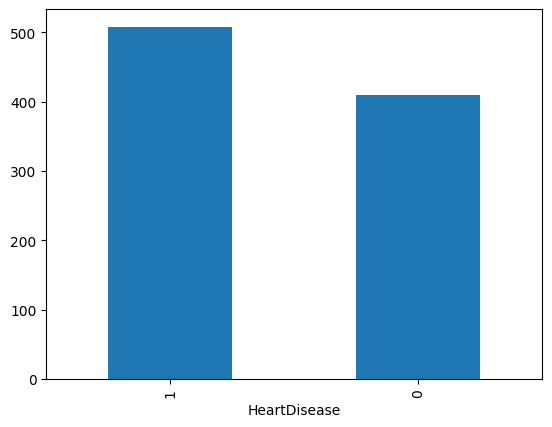

In [13]:
df['HeartDisease'].value_counts().plot(kind='bar')

In [14]:
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


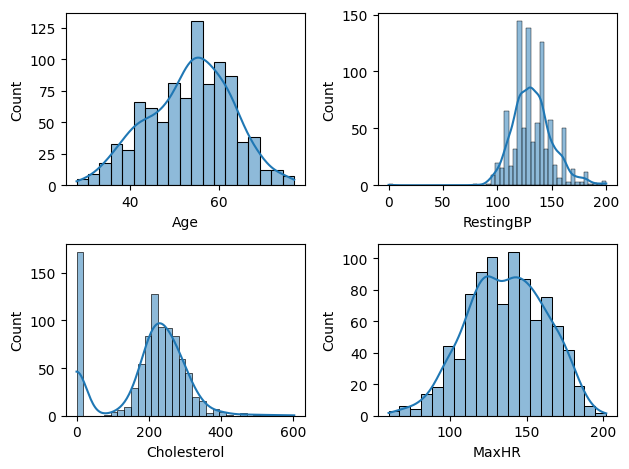

In [15]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()



In [16]:
df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


In [17]:
ch_mean = df.loc[df['Cholesterol'] != 0,'Cholesterol'].mean()
ch_mean

np.float64(244.6353887399464)

In [18]:
df['Cholesterol'] = df['Cholesterol'].replace(0,ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

In [19]:
resBP_mean = df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,resBP_mean)
df['RestingB'] = df['RestingBP'].round(2)

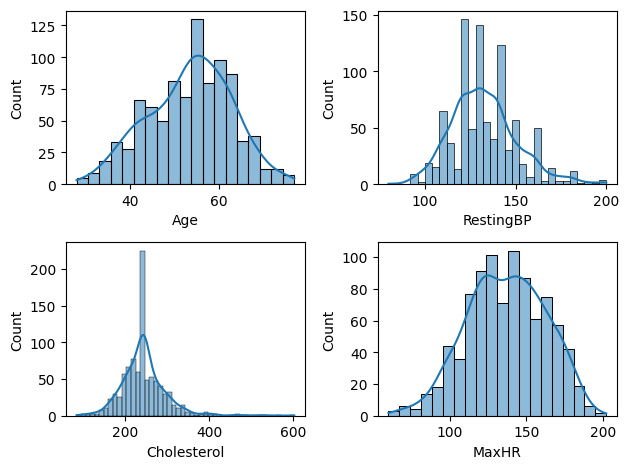

In [20]:
def plotting(var,num):
  plt.subplot(2,2,num)
  sns.histplot(df[var],kde=True)
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)

plt.tight_layout()

<Axes: xlabel='Sex', ylabel='count'>

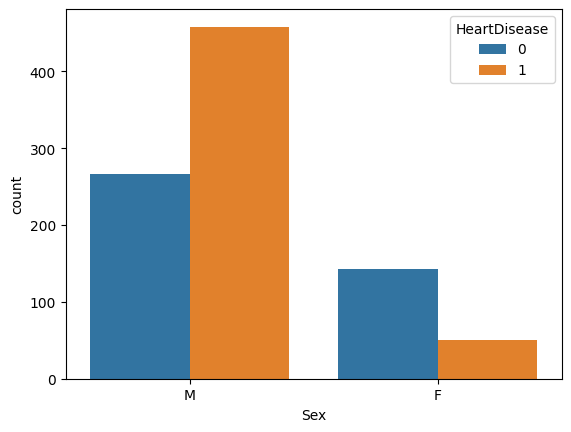

In [21]:
sns.countplot(x = df['Sex'],hue = df['HeartDisease'])

<Axes: xlabel='ChestPainType', ylabel='count'>

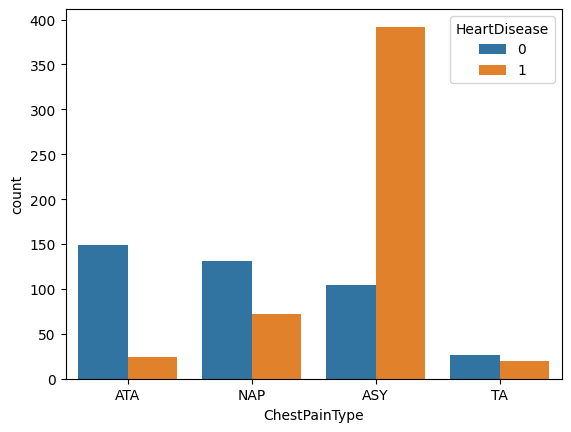

In [22]:
sns.countplot(x = df['ChestPainType'],hue= df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

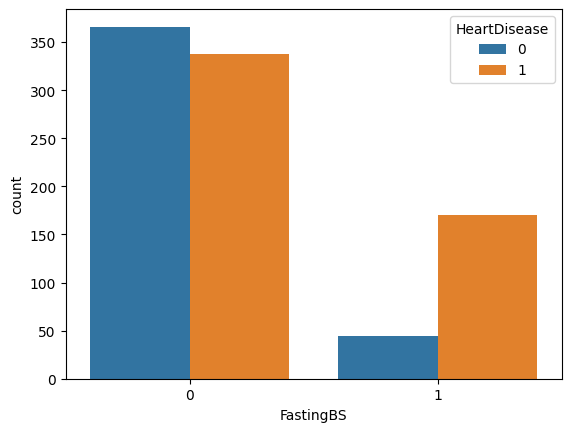

In [23]:
sns.countplot(x = df['FastingBS'],hue= df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

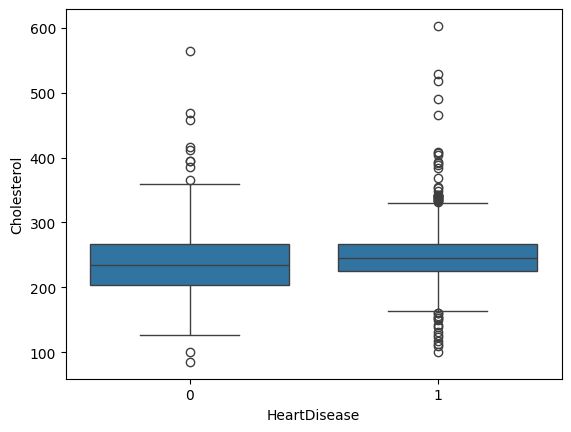

In [24]:
sns.boxplot(x = df['HeartDisease'],y = df['Cholesterol'])

<Axes: xlabel='HeartDisease', ylabel='Age'>

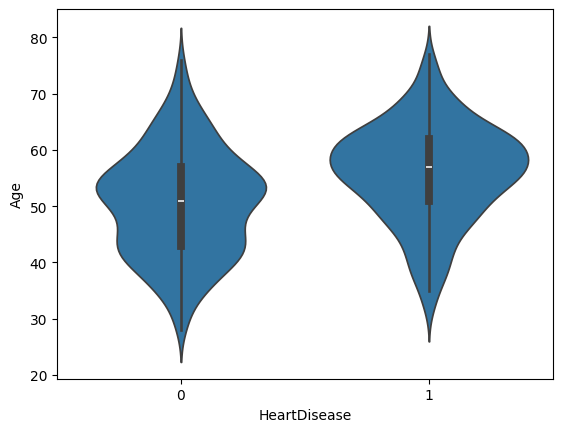

In [25]:
sns.violinplot(x = df['HeartDisease'], y =df['Age'])

<Axes: >

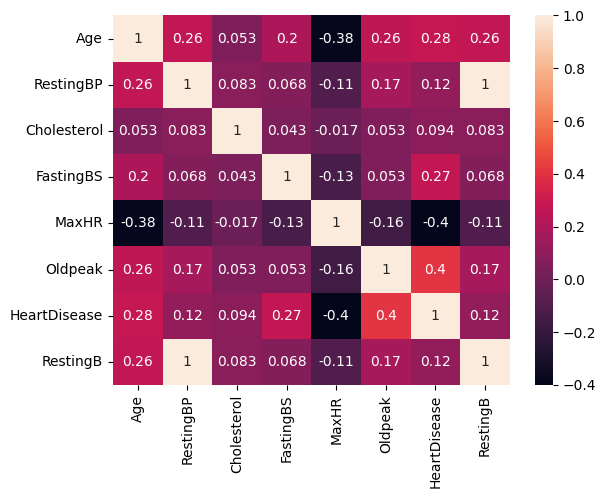

In [26]:
sns.heatmap(df.corr(numeric_only = True), annot=True)

DATA PREPROCESSING AND CLEANING

In [27]:
df_encode = pd.get_dummies(df,drop_first=True)
df_encode = df_encode.astype(int)

In [28]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,RestingB,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,140,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,160,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,130,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,138,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,150,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,110,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,144,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,130,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,130,0,1,0,0,0,0,0,1,0


In [29]:
from sklearn.preprocessing import StandardScaler
numercal_cols=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler = StandardScaler()
df_encode[numercal_cols] = scaler.fit_transform(df_encode[numercal_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,RestingB,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.433140,0.414885,0.834754,0,1.382928,-0.727592,0,140,1,1,0,0,1,0,0,0,1
1,-0.478484,1.527224,-1.210675,0,0.754157,0.282891,1,160,0,0,1,0,1,0,0,1,0
2,-1.751359,-0.141284,0.722161,0,-1.525138,-0.727592,0,130,1,1,0,0,0,1,0,0,1
3,-0.584556,0.303651,-0.572651,0,-1.132156,0.282891,1,138,0,0,0,0,1,0,1,1,0
4,0.051881,0.971054,-0.929194,0,-0.581981,-0.727592,0,150,1,0,1,0,1,0,0,0,1


In [30]:
df_encode.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'RestingB', 'Sex_M', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal',
       'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [32]:
X = df_encode.drop('HeartDisease',axis=1)
Y = df_encode['HeartDisease']

In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [34]:
scaler = StandardScaler()
X_train_Scaled = scaler.fit_transform(X_train)
X_test_Scaled = scaler.fit_transform(X_test)


In [35]:
models = {
    "logistic regression" : LogisticRegression(),
    "KNN" : KNeighborsClassifier(),
    "NaiveBayes" : GaussianNB(),
    "DescisionTree" : DecisionTreeClassifier(),
    "SVM" : SVC()
}


In [36]:
result = []

##  Baseline: 5-Fold Stratified Cross-Validation

In [37]:
from sklearn.model_selection import GridSearchCV

In [41]:
# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN'                : KNeighborsClassifier(),
    'Naive Bayes'        : GaussianNB(),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'SVM'                : SVC(probability=True, random_state=42)
}

cv_results = {}

for name, model in models.items():
    acc_scores = cross_val_score(model, X_train_Scaled, Y_train, cv=skf, scoring='accuracy')
    f1_scores  = cross_val_score(model, X_train_Scaled, Y_train, cv=skf, scoring='f1')
    cv_results[name] = {
        'Accuracy Mean' : acc_scores.mean(),
        'Accuracy Std'  : acc_scores.std(),
        'F1 Mean'       : f1_scores.mean(),
        'F1 Std'        : f1_scores.std()
    }
    print(f'{name:25s} | Acc: {acc_scores.mean():.4f} ± {acc_scores.std():.4f} | F1: {f1_scores.mean():.4f} ± {f1_scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).T
cv_df

Logistic Regression       | Acc: 0.8638 ± 0.0167 | F1: 0.8777 ± 0.0155
KNN                       | Acc: 0.8365 ± 0.0148 | F1: 0.8564 ± 0.0131
Naive Bayes               | Acc: 0.8501 ± 0.0162 | F1: 0.8636 ± 0.0140
Decision Tree             | Acc: 0.7602 ± 0.0394 | F1: 0.7816 ± 0.0353
SVM                       | Acc: 0.8501 ± 0.0224 | F1: 0.8675 ± 0.0194


,Accuracy Mean,Accuracy Std,F1 Mean,F1 Std
Logistic Regression,0.863759,0.016667,0.877693,0.015458
KNN,0.836520,0.014812,0.856438,0.013067
Naive Bayes,0.850126,0.016194,0.863587,0.014037
Decision Tree,0.760199,0.039405,0.781635,0.035307
SVM,0.850135,0.022360,0.867526,0.019447


##  Hyperparameter Tuning : GridSearchCV

In [43]:
#  Logistic Regression
param_grid_lr = {
    'C'      : [0.01, 0.1, 1, 10, 100],
    'solver' : ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr, cv=skf, scoring='f1', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_Scaled, Y_train)
print(f'Best LR Params : {grid_lr.best_params_}')
print(f'Best LR F1 (CV): {grid_lr.best_score_:.4f}')

Best LR Params : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best LR F1 (CV): 0.8816


In [45]:
#  KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['euclidean', 'manhattan']
}
grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn, cv=skf, scoring='f1', n_jobs=-1
)
grid_knn.fit(X_train_Scaled, Y_train)
print(f'Best KNN Params : {grid_knn.best_params_}')
print(f'Best KNN F1 (CV): {grid_knn.best_score_:.4f}')

Best KNN Params : {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Best KNN F1 (CV): 0.8781


In [46]:
#  SVM
param_grid_svm = {
    'C'      : [0.1, 1, 10, 100],
    'kernel' : ['rbf', 'linear'],
    'gamma'  : ['scale', 'auto']
}
grid_svm = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid_svm, cv=skf, scoring='f1', n_jobs=-1
)
grid_svm.fit(X_train_Scaled, Y_train)
print(f'Best SVM Params : {grid_svm.best_params_}')
print(f'Best SVM F1 (CV): {grid_svm.best_score_:.4f}')

Best SVM Params : {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best SVM F1 (CV): 0.8775


In [47]:
#  Decision Tree
param_grid_dt = {
    'max_depth'       : [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'criterion'        : ['gini', 'entropy']
}
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=skf, scoring='f1', n_jobs=-1
)
grid_dt.fit(X_train_Scaled, Y_train)
print(f'Best DT Params : {grid_dt.best_params_}')
print(f'Best DT F1 (CV): {grid_dt.best_score_:.4f}')

Best DT Params : {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best DT F1 (CV): 0.8466


##  Final Evaluation on Test Set

In [50]:
tuned_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'KNN'                : grid_knn.best_estimator_,
    'Naive Bayes'        : GaussianNB(),
    'Decision Tree'      : grid_dt.best_estimator_,
    'SVM'                : grid_svm.best_estimator_
}

# Fit Naive Bayes
tuned_models['Naive Bayes'].fit(X_train_Scaled, Y_train)

results = []
for name, model in tuned_models.items():
    y_pred = model.predict(X_test_Scaled)
    acc    = accuracy_score(Y_test, y_pred)
    f1     = f1_score(Y_test, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'F1 Score': f1})
    print(f'{name:25s} | Accuracy: {acc:.4f} | F1: {f1:.4f}')

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
results_df

Logistic Regression       | Accuracy: 0.8641 | F1: 0.8804
KNN                       | Accuracy: 0.8587 | F1: 0.8762
Naive Bayes               | Accuracy: 0.8533 | F1: 0.8683
Decision Tree             | Accuracy: 0.7989 | F1: 0.8230
SVM                       | Accuracy: 0.8587 | F1: 0.8750


,Model,Accuracy,F1 Score
0,Logistic Regression,0.864130,0.880383
1,KNN,0.858696,0.876190
4,SVM,0.858696,0.875000
2,Naive Bayes,0.853261,0.868293
3,Decision Tree,0.798913,0.822967


##  ROC Curves : All Models

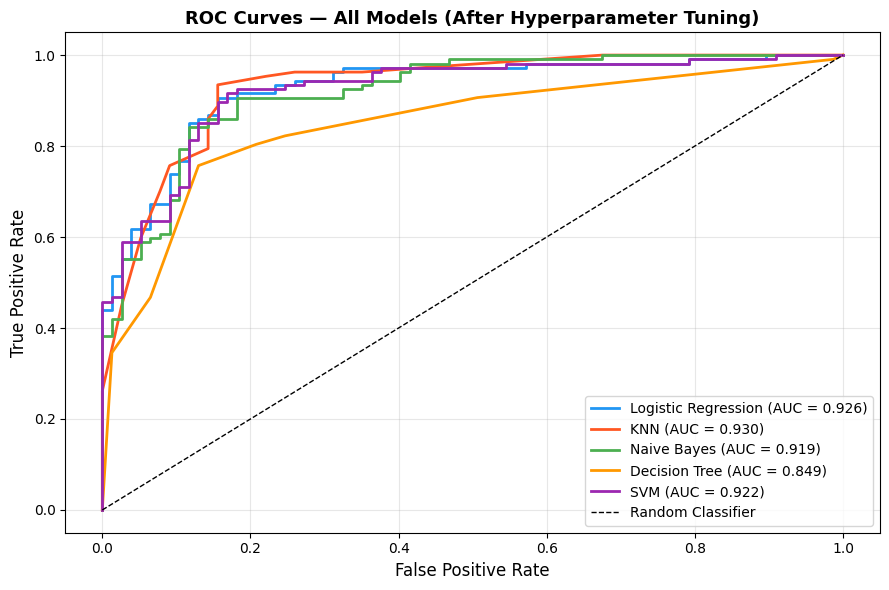

In [54]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

for (name, model), color in zip(tuned_models.items(), colors):
    y_prob = model.predict_proba(X_test_Scaled)[:, 1]
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    auc = roc_auc_score(Y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (After Hyperparameter Tuning)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrix : Best Model

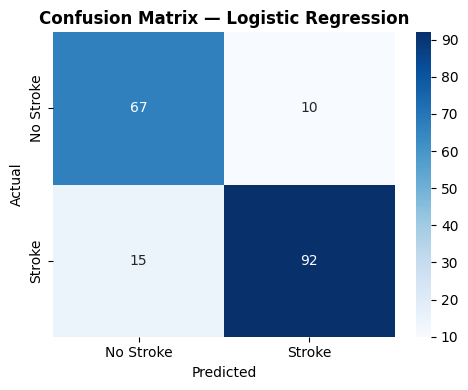


Classification Report : Logistic Regression:
              precision    recall  f1-score   support

   No Stroke       0.82      0.87      0.84        77
      Stroke       0.90      0.86      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184



In [62]:
best_model_name = results_df.iloc[0]['Model']
best_model      = tuned_models[best_model_name]
y_pred_best     = best_model.predict(X_test_Scaled)

cm = confusion_matrix(Y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Stroke', 'Stroke'],
            yticklabels=['No Stroke', 'Stroke'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report : {best_model_name}:')
print(classification_report(Y_test, y_pred_best, target_names=['No Stroke', 'Stroke']))

## CV vs Tuned : Performance Comparison Plot

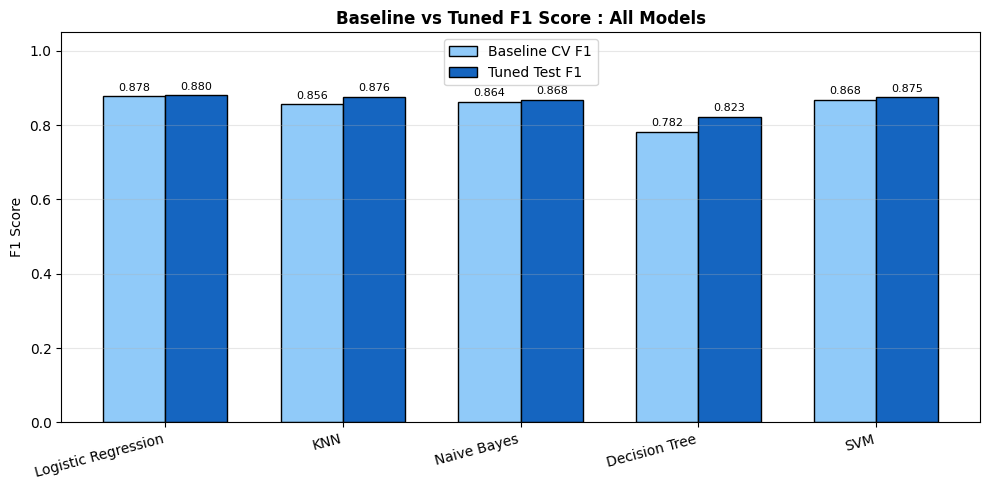

In [63]:
model_names = list(cv_results.keys())
cv_f1       = [cv_results[m]['F1 Mean'] for m in model_names]
tuned_f1    = [results_df[results_df['Model'] == m]['F1 Score'].values[0] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, cv_f1,    width, label='Baseline CV F1',    color='#90CAF9', edgecolor='black')
bars2 = ax.bar(x + width/2, tuned_f1, width, label='Tuned Test F1',     color='#1565C0', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Baseline vs Tuned F1 Score : All Models', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('cv_vs_tuned.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
print(f'Saved: {best_model_name} as best_model.pkl')
print('Saved: scaler.pkl')

Saved: Logistic Regression as best_model.pkl
Saved: scaler.pkl
